# Traffic Sign Inventory - data exploration + YOLO11 training (Colab free)

Runs end to end on a free T4. Order matters, so work top to bottom the first time.

| Phase | What happens | Re-run each session? |
|---|---|---|
| A | Verify the raw ARTSv2 files and their XML field names | no, once |
| B | Explore the data (classes, box sizes, GPS coverage) | no, once |
| C | Convert to YOLO format, cache a zip on Drive | no, once |
| D | Unzip to local disk, then train | **yes, every session** |
| E | Evaluate on the held-out test split | at the end |

**Why the zip:** the dataset lives on Drive (permanent, 5 TB), but training reads
thousands of small files. Reading those over Drive's network filesystem is far
slower than the GPU, so each session copies one zip to the session's local SSD
and trains from there. Checkpoints still go straight back to Drive.

**Survival rules for the free tier**
1. `save_period=2` writes a checkpoint to Drive every 2 epochs
2. `project=` always points at Drive, never only at `/content`
3. Session died? Re-run **Phase D unzip**, then the **Resume** cell. Never restart from epoch 0.
4. CUDA OOM? `batch=8`, then `imgsz=512`, and stay on `yolo11n`

## Phase A - setup and verification

In [1]:
# A1. Mount Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# A2. Install
!pip -q install ultralytics
import ultralytics; ultralytics.checks()

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [3]:
# A3. Paths. EDIT THESE TWO if your folders differ.
import os

DRIVE_ROOT = "/content/drive/MyDrive/traffic-sign-inventory"
ARTS_ROOT  = f"{DRIVE_ROOT}/datasets/arts_v2"     # must contain Annotations/ + JPEGImages/
#   The ARTSv2 folder on Drive is named "challenging_dom" - either rename it to
#   arts_v2, or point ARTS_ROOT at it directly.
REPO_DIR   = f"{DRIVE_ROOT}/repo"                 # copy of this project folder

# Derived - no need to change
LOCAL_DATASET = "/content/dataset/arts_yolo"      # fast local disk, wiped each session
DATASET_ZIP   = f"{DRIVE_ROOT}/datasets/arts_yolo.zip"   # permanent cache on Drive
PROJECT       = f"{DRIVE_ROOT}/runs"              # checkpoints, on Drive
NAME          = "yolo11n_arts"
DATA_YAML     = f"{LOCAL_DATASET}/data.yaml"

os.makedirs(f"{DRIVE_ROOT}/datasets", exist_ok=True)
os.makedirs(PROJECT, exist_ok=True)

print("raw dataset :", ARTS_ROOT, "->", os.path.isdir(ARTS_ROOT))
print("repo        :", REPO_DIR, "->", os.path.isdir(REPO_DIR))
print("dataset zip :", DATASET_ZIP, "->", os.path.isfile(DATASET_ZIP))

import torch
print("\nCUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"{p.name}  {p.total_memory/1e9:.1f} GB VRAM")
else:
    print("No GPU. Runtime -> Change runtime type -> T4 GPU, then re-run.")
!df -h /content | tail -1

raw dataset : /content/drive/MyDrive/traffic-sign-inventory/datasets/arts_v2 -> True
repo        : /content/drive/MyDrive/traffic-sign-inventory/repo -> True
dataset zip : /content/drive/MyDrive/traffic-sign-inventory/datasets/arts_yolo.zip -> True

CUDA: True
Tesla T4  15.6 GB VRAM
overlay         113G   48G   66G  42% /


In [ ]:
# A4. If the repo is not on Drive yet, put it there.
# Easiest: upload the project folder to MyDrive/traffic-sign-inventory/repo
# (node_modules excluded - it is not needed on Colab).
# Or, if you have pushed it to GitHub, uncomment and set your URL:

# !git clone https://github.com/YOUR_USERNAME/YOUR_REPO.git {REPO_DIR}

assert os.path.isdir(f"{REPO_DIR}/scripts"), (
    f"scripts/ not found under {REPO_DIR}. Copy the project folder to Drive first."
)
print(sorted(os.listdir(f"{REPO_DIR}/scripts")))

In [ ]:
# A5. VERIFY THE RAW DATA. Do not skip this cell.
# Prints one complete annotation so you see the real field names yourself.
import glob, os, time

t0 = time.time()
ann_dir = os.path.join(ARTS_ROOT, "Annotations")
img_dir = os.path.join(ARTS_ROOT, "JPEGImages")

if os.path.isdir(ann_dir) and os.path.isdir(img_dir):
    # ARTSv2 is a flat PASCAL VOC layout - two listings, not a recursive walk
    print("PASCAL VOC layout detected (expected for ARTSv2)")
    xml_files = [os.path.join(ann_dir, f) for f in os.listdir(ann_dir) if f.lower().endswith(".xml")]
    img_files = [os.path.join(img_dir, f) for f in os.listdir(img_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
else:
    print("No Annotations/ + JPEGImages/ here - scanning recursively (slow on Drive)...")
    xml_files = glob.glob(f"{ARTS_ROOT}/**/*.xml", recursive=True)
    img_files = []
    for ext in ("jpg", "jpeg", "png", "JPG", "PNG"):
        img_files += glob.glob(f"{ARTS_ROOT}/**/*.{ext}", recursive=True)

print(f"XML files  : {len(xml_files)}")
print(f"image files: {len(img_files)}")
print(f"(listing took {time.time()-t0:.0f}s)")
assert xml_files, (
    f"No XML under {ARTS_ROOT}.\n"
    "Check that ARTS_ROOT points at the folder CONTAINING Annotations/ and JPEGImages/.\n"
    "If you used a Drive shortcut, open it once in the Drive web UI so it resolves."
)

print("\ntop-level entries:", sorted(os.listdir(ARTS_ROOT))[:20])
print("\nexample XML:", xml_files[0])
print("=" * 70)
print(open(xml_files[0], encoding="utf-8", errors="replace").read()[:4000])
print("=" * 70)
print("""
EXPECTED for ARTSv2 - check you see all of these:
  <Location><Latitude> <Longitude> <Cam_DOM>     camera position + heading
  <object><id>CLASS_lat_lon</id>                 stable physical-sign id
  <object><location><latitude>                   the sign's own position
  <object><bndbox>                               the box
If any are missing or named differently, stop and report it before converting.
""")

In [ ]:
# A6. Read the metadata ARTSv2 ships in ImageSets/. Free information -- the
# authors' own class list, code->description lookup, and split statistics.
import os, glob

for path in sorted(glob.glob(f"{ARTS_ROOT}/ImageSets/**/*.txt", recursive=True)):
    name = os.path.basename(path)
    if name.endswith(("_train.txt", "_val.txt", "_test.txt", "_trainval.txt")) and "stats" not in name:
        continue          # the per-class VOC membership lists, hundreds of them
    size = os.path.getsize(path)
    print("=" * 70)
    print(f"{os.path.relpath(path, ARTS_ROOT)}   ({size} bytes)")
    print("=" * 70)
    with open(path, encoding="utf-8", errors="replace") as f:
        text = f.read()
    lines = text.splitlines()
    print(f"{len(lines)} lines")
    for line in lines[:25]:
        print("  ", line)
    if len(lines) > 25:
        print(f"   ... {len(lines)-25} more")
    print()

# How many official split lists are there, and how big?
main = glob.glob(f"{ARTS_ROOT}/ImageSets/Main/*.txt")
print(f"ImageSets/Main: {len(main)} files (VOC per-class membership lists)")
for suffix in ("_train.txt", "_val.txt", "_test.txt", "_trainval.txt"):
    hits = [m for m in main if m.endswith(suffix)]
    if hits:
        print(f"  {suffix:14s} {len(hits)} classes, e.g. {os.path.basename(hits[0])}")

## Phase A7 - copy the dataset to local disk (do this before Phase B)

Reading files one at a time off the Drive mount runs at roughly **1 file per
second**: every open is a network round-trip, and shortcuts to shared folders are
the worst case. At that rate Phase B alone takes 5 hours and Phase C takes 11.

The fix is concurrency, not patience. Drive is latency-bound, so 32 threads
waiting on 32 round-trips at once is ~30x faster than one thread waiting on one.
This cell copies the whole dataset to the session's local SSD, after which every
later cell reads at full speed.

Run it once per session. If your runtime dies, run it again.

In [ ]:
# A7. Parallel copy: Drive -> local SSD.
import os, shutil, time
from concurrent.futures import ThreadPoolExecutor

LOCAL_RAW = "/content/arts_raw"
WORKERS = 32          # raise to 64 if the benchmark below still looks slow
SUBSET_N = 0          # 0 = whole dataset. Set e.g. 6000 if Drive throttles you;
                      # a 6k-image subset still trains a solid model.

if os.path.isdir(f"{LOCAL_RAW}/Annotations") and os.path.isdir(f"{LOCAL_RAW}/JPEGImages"):
    print("already copied to local disk")
else:
    # ---- build the file list (directory listings, not file reads) ----
    t0 = time.time()
    tasks = []
    for sub in ("Annotations", "JPEGImages", "ImageSets"):
        src_dir = os.path.join(ARTS_ROOT, sub)
        if not os.path.isdir(src_dir):
            continue
        for root, _, files in os.walk(src_dir):
            rel = os.path.relpath(root, ARTS_ROOT)
            os.makedirs(os.path.join(LOCAL_RAW, rel), exist_ok=True)
            for name in files:
                tasks.append((os.path.join(root, name),
                              os.path.join(LOCAL_RAW, rel, name)))
    if SUBSET_N:
        # keep ImageSets whole, but take only the first N annotation/image stems
        meta = [t for t in tasks if "ImageSets" in t[0]]
        ann = sorted(t for t in tasks if os.sep + "Annotations" + os.sep in t[0])[:SUBSET_N]
        keep = {os.path.splitext(os.path.basename(s))[0] for s, _ in ann}
        img = [t for t in tasks
               if os.sep + "JPEGImages" + os.sep in t[0]
               and os.path.splitext(os.path.basename(t[0]))[0] in keep]
        tasks = meta + ann + img
        print(f"SUBSET_N={SUBSET_N}: copying {len(ann)} annotations + {len(img)} images")

    print(f"{len(tasks)} files to copy (listed in {time.time()-t0:.0f}s)")

    def copy_one(pair):
        src, dst = pair
        if os.path.exists(dst) and os.path.getsize(dst) > 0:
            return 0                      # resume-friendly
        try:
            shutil.copyfile(src, dst)
            return os.path.getsize(dst)
        except OSError:
            return -1

    # ---- quick benchmark so you can see the speedup is real ----
    # ~30s: 24 files serially, then the same 24 in parallel
    probe = [t for t in tasks if t[0].endswith(".xml")][:24]
    if probe:
        print("benchmarking (about 30 seconds)...")
        rates = {}
        for w in (1, WORKERS):
            for _, dst in probe:
                if os.path.exists(dst):
                    os.remove(dst)
            t1 = time.time()
            with ThreadPoolExecutor(max_workers=w) as ex:
                list(ex.map(copy_one, probe))
            rates[w] = len(probe) / (time.time() - t1)
            print(f"  {w:3d} thread(s): {rates[w]:6.1f} files/s")

        speedup = rates[WORKERS] / max(rates[1], 1e-9)
        eta = len(tasks) / max(rates[WORKERS], 1e-9) / 60
        print(f"speedup: {speedup:.1f}x   estimated full copy: {eta:.0f} min")
        if speedup < 3:
            print(" !! Parallelism is not helping -- Drive is likely throttling you.")
            print("!! Options, in order of preference:")
            print("!!   1. raise WORKERS to 64 and re-run this cell")
            print("!!   2. set SUBSET_N = 6000 and re-run (still a solid dataset)")
            print("!!   3. tell me and I will switch to the Drive API, which")
            print("!!      bypasses the FUSE mount entirely")
        elif eta > 90:
            print("!! Over 90 minutes. Consider SUBSET_N = 6000 to stay inside one session.")

    # ---- the real copy ----
    print(f"\ncopying with {WORKERS} threads...")
    t0 = time.time()
    done = bytes_copied = failed = 0
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        for size in ex.map(copy_one, tasks):
            done += 1
            if size < 0:
                failed += 1
            else:
                bytes_copied += size
            if done % 1000 == 0:
                elapsed = time.time() - t0
                rate = done / elapsed
                print(f"  {done}/{len(tasks)}  {rate:.0f} files/s  "
                      f"{bytes_copied/1e9:.1f} GB  ~{(len(tasks)-done)/rate/60:.0f} min left")
    print(f"\ncopied {done} files ({bytes_copied/1e9:.2f} GB) in {(time.time()-t0)/60:.1f} min")
    if failed:
        print(f"  {failed} failed -- re-run this cell, it skips what is already there")

# Point everything downstream at the local copy.
ARTS_ROOT = LOCAL_RAW
print("\nARTS_ROOT is now:", ARTS_ROOT)
print("NOTE: re-running cell A3 resets this. If you do, re-run A7 too.")
!du -sh {LOCAL_RAW} 2>/dev/null
!df -h /content | tail -1

40526 files to copy (listed in 72s)
benchmarking (about 30 seconds)...
    1 thread(s):    1.0 files/s
   32 thread(s):  706.2 files/s
speedup: 713.3x   estimated full copy: 1 min

copying with 32 threads...
  1000/40526  3 files/s  0.0 GB  ~203 min left
  2000/40526  6 files/s  0.0 GB  ~100 min left
  3000/40526  10 files/s  0.0 GB  ~65 min left
  4000/40526  13 files/s  0.0 GB  ~48 min left
  5000/40526  16 files/s  0.0 GB  ~38 min left
  6000/40526  19 files/s  0.0 GB  ~31 min left
  7000/40526  22 files/s  0.0 GB  ~26 min left
  8000/40526  25 files/s  0.0 GB  ~22 min left
  9000/40526  28 files/s  0.0 GB  ~19 min left
  10000/40526  31 files/s  0.0 GB  ~17 min left
  11000/40526  34 files/s  0.0 GB  ~15 min left
  12000/40526  37 files/s  0.0 GB  ~13 min left
  13000/40526  39 files/s  0.0 GB  ~12 min left
  14000/40526  42 files/s  0.0 GB  ~10 min left
  15000/40526  45 files/s  0.0 GB  ~9 min left
  16000/40526  48 files/s  0.0 GB  ~9 min left
  17000/40526  50 files/s  0.0 GB  

## Phase B - data exploration

This is what tells you whether the dataset can support the project: how skewed
the classes are, how small the signs are in pixels (which drives `imgsz`), and
whether the GPS actually covers a route.

In [ ]:
# B1. Parse every annotation once and keep the raw numbers in memory.
# Self-contained: builds its own file list from the local copy made in A7.
import os, time
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

assert ARTS_ROOT.startswith("/content/"), "Run cell A7 first."

ann_dir = os.path.join(ARTS_ROOT, "Annotations")
img_dir = os.path.join(ARTS_ROOT, "JPEGImages")
xml_files = sorted(os.path.join(ann_dir, f) for f in os.listdir(ann_dir)
                   if f.lower().endswith(".xml"))
img_files = sorted(os.path.join(img_dir, f) for f in os.listdir(img_dir)
                   if f.lower().endswith((".jpg", ".jpeg", ".png")))
print(f"XML: {len(xml_files)}   images: {len(img_files)}")


def flatten(node, skip=("object",)):
    """Flatten to {lowercased tag: text}, recursing into containers.
    ARTSv2 nests camera GPS under <Location>, so a direct-children scan
    finds nothing. skip prunes <object> so a sign's latitude is never
    mistaken for the camera's."""
    out = {}
    def walk(n):
        for ch in n:
            tag = (ch.tag or "").lower()
            if tag in skip:
                continue
            if len(ch) == 0:
                if ch.text and ch.text.strip():
                    out.setdefault(tag, ch.text.strip())
            else:
                walk(ch)
    walk(node)
    return out


def as_float(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


records, per_image = [], []
class_counter = Counter()
bad = 0
t0 = time.time()

for i, xml_path in enumerate(xml_files):
    if i and i % 5000 == 0:
        print(f"  {i}/{len(xml_files)}  ({i/(time.time()-t0):.0f}/s)")
    try:
        root = ET.parse(xml_path).getroot()
    except ET.ParseError:
        bad += 1
        continue

    size = root.find("size")
    W = as_float(size.findtext("width")) if size is not None else None
    H = as_float(size.findtext("height")) if size is not None else None
    if not W or not H:
        bad += 1
        continue

    img = flatten(root)                      # <object> pruned
    cam_lat, cam_lon = as_float(img.get("latitude")), as_float(img.get("longitude"))
    heading = as_float(img.get("cam_dom"))

    objects = root.findall(".//object")
    sign_ids = set()
    for obj in objects:
        name = (obj.findtext("name") or "").strip()
        bb = obj.find("bndbox")
        if not name or bb is None:
            continue
        x1, y1 = as_float(bb.findtext("xmin")), as_float(bb.findtext("ymin"))
        x2, y2 = as_float(bb.findtext("xmax")), as_float(bb.findtext("ymax"))
        if None in (x1, y1, x2, y2) or x2 <= x1 or y2 <= y1:
            continue

        of = flatten(obj, skip=())            # keep <location> here
        sid = (obj.findtext("id") or "").strip()
        if sid:
            sign_ids.add(sid)
        class_counter[name] += 1
        records.append({
            "cls": name,
            "w_px": x2 - x1, "h_px": y2 - y1,
            "rel_area": ((x2 - x1) * (y2 - y1)) / (W * H),
            "img_w": W, "img_h": H,
            "sign_lat": as_float(of.get("latitude")),
            "sign_lon": as_float(of.get("longitude")),
            "cam_lat": cam_lat, "cam_lon": cam_lon,
            "folder": "Annotations",
        })

    per_image.append({
        "stem": os.path.splitext(os.path.basename(xml_path))[0],
        "sign_ids": sign_ids,
        "n_obj": len(objects), "w": W, "h": H,
        "cam_lat": cam_lat, "cam_lon": cam_lon, "heading": heading,
        "folder": "Annotations",
    })

print()
print(f"parsed in {time.time()-t0:.0f}s")
print(f"images parsed    : {len(per_image)}")
print(f"annotations      : {len(records)}")
print(f"distinct classes : {len(class_counter)}")
print(f"unreadable XML   : {bad}")
print(f"images with GPS  : {sum(1 for p in per_image if p['cam_lat'] is not None)}")
print(f"images w/ heading: {sum(1 for p in per_image if p['heading'] is not None)}")
print(f"unique physical signs: {len(set().union(*[p['sign_ids'] for p in per_image]) if per_image else set())}")

XML: 19914   images: 19914
  5000/19914  (879/s)
  10000/19914  (1168/s)
  15000/19914  (1408/s)

parsed in 12s
images parsed    : 19914
annotations      : 35979
distinct classes : 171
unreadable XML   : 0
images with GPS  : 19914
images w/ heading: 19914
unique physical signs: 7773


top  10 classes cover  33.0% of all annotations
top  20 classes cover  49.2% of all annotations
top  30 classes cover  60.6% of all annotations
top  50 classes cover  75.1% of all annotations
top 100 classes cover  91.9% of all annotations

classes with fewer than 10 examples: 0 / 171  <- unlearnable, drop them


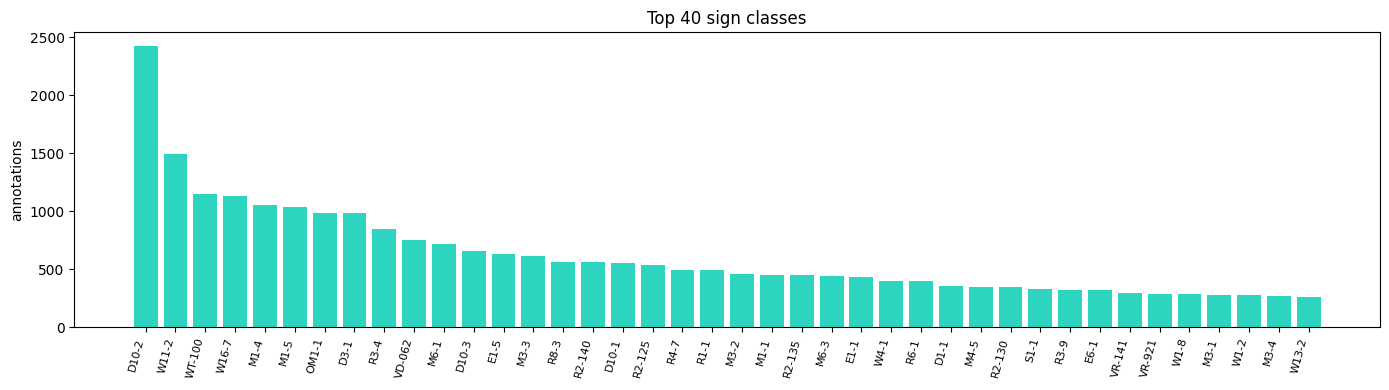

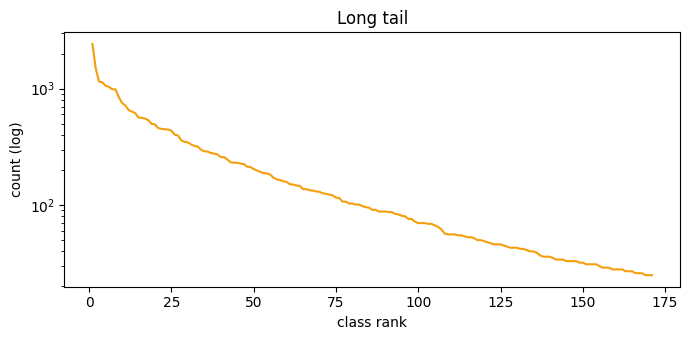

In [ ]:
# B2. Class distribution - the long tail is the reason we keep only the top N.
import matplotlib.pyplot as plt

ordered = class_counter.most_common()
counts = [c for _, c in ordered]
total = sum(counts)

for n in (10, 20, 30, 50, 100):
    if n <= len(counts):
        share = 100 * sum(counts[:n]) / total
        print(f"top {n:3d} classes cover {share:5.1f}% of all annotations")

singles = sum(1 for c in counts if c < 10)
print(f"\nclasses with fewer than 10 examples: {singles} / {len(counts)}  <- unlearnable, drop them")

fig, ax = plt.subplots(figsize=(14, 4))
show = ordered[:40]
ax.bar(range(len(show)), [c for _, c in show], color="#2dd4bf")
ax.set_xticks(range(len(show)))
ax.set_xticklabels([n for n, _ in show], rotation=75, ha="right", fontsize=8)
ax.set_ylabel("annotations")
ax.set_title("Top 40 sign classes")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, len(counts) + 1), counts, color="#f59e0b")
ax.set_yscale("log"); ax.set_xlabel("class rank"); ax.set_ylabel("count (log)")
ax.set_title("Long tail"); plt.tight_layout(); plt.show()

median sign occupies 0.050% of the frame
median box side      26 px

tiny   (<16 px):  20.4%
small  (<32 px):  60.5%
medium (<96 px):  94.9%


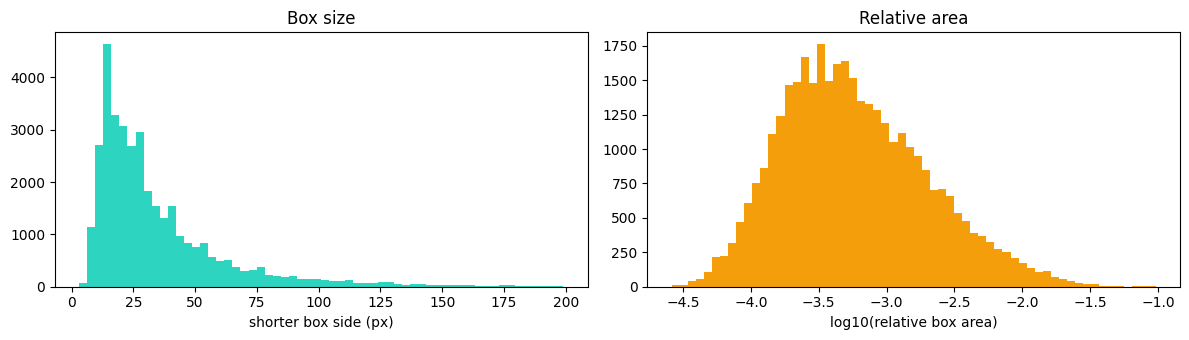


Rule of thumb: if most boxes are under 32 px at native resolution,
do NOT train at imgsz=416. Keep 640, and consider 800 if VRAM allows.


In [ ]:
# B3. How big are the signs in pixels? This decides imgsz.
import numpy as np

rel = np.array([r["rel_area"] for r in records])
side = np.sqrt(rel)
print(f"median sign occupies {100*np.median(rel):.3f}% of the frame")
print(f"median box side      {np.median([min(r['w_px'], r['h_px']) for r in records]):.0f} px")

# COCO-style size buckets, computed on the box's shorter side
short = np.array([min(r["w_px"], r["h_px"]) for r in records])
print(f"\ntiny   (<16 px): {100*(short < 16).mean():5.1f}%")
print(f"small  (<32 px): {100*(short < 32).mean():5.1f}%")
print(f"medium (<96 px): {100*(short < 96).mean():5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(short[short < 200], bins=60, color="#2dd4bf")
axes[0].set_xlabel("shorter box side (px)"); axes[0].set_title("Box size")
axes[1].hist(np.log10(rel + 1e-9), bins=60, color="#f59e0b")
axes[1].set_xlabel("log10(relative box area)"); axes[1].set_title("Relative area")
plt.tight_layout(); plt.show()

print("\nRule of thumb: if most boxes are under 32 px at native resolution,")
print("do NOT train at imgsz=416. Keep 640, and consider 800 if VRAM allows.")

In [ ]:
# B4. Image resolution and objects per image
res = Counter((int(p["w"]), int(p["h"])) for p in per_image)
print("most common resolutions:")
for (w, h), n in res.most_common(5):
    print(f"  {w}x{h}: {n} images")

n_obj = np.array([p["n_obj"] for p in per_image])
print(f"\nobjects per image: mean {n_obj.mean():.2f}  median {np.median(n_obj):.0f}  max {n_obj.max()}")
print(f"images with no objects: {(n_obj == 0).sum()}")

per_folder = Counter(p["folder"] for p in per_image)
sizes = sorted(per_folder.values())
print(f"\nframes per folder: min {sizes[0]}  median {sizes[len(sizes)//2]}  max {sizes[-1]}")
print("If folders look like road segments, the converter will split on them (no leakage).")

most common resolutions:
  1920x1080: 19914 images

objects per image: mean 1.81  median 1  max 26
images with no objects: 0

frames per folder: min 19914  median 19914  max 19914
If folders look like road segments, the converter will split on them (no leakage).


19914 located frames
lat 42.7360 .. 45.0095
lon -73.2926 .. -71.5952


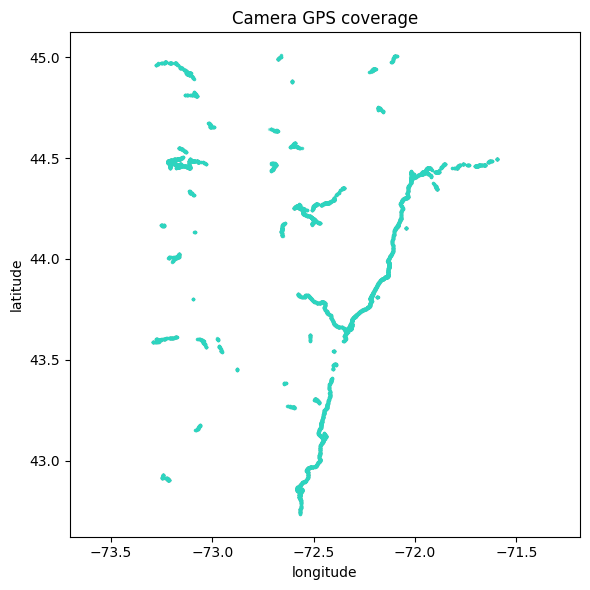

In [ ]:
# B5. Geographic coverage - does the GPS trace an actual route?
pts = [(p["cam_lat"], p["cam_lon"]) for p in per_image if p["cam_lat"] is not None]
if not pts:
    print("No camera GPS found at image level. Geo-localization metrics will be unavailable")
    print("unless the GPS lives in a sidecar file - check the output of cell A5.")
else:
    lats = [a for a, _ in pts]; lons = [b for _, b in pts]
    print(f"{len(pts)} located frames")
    print(f"lat {min(lats):.4f} .. {max(lats):.4f}")
    print(f"lon {min(lons):.4f} .. {max(lons):.4f}")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(lons, lats, s=2, alpha=0.4, color="#2dd4bf")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.set_title("Camera GPS coverage"); ax.set_aspect("equal", "datalim")
    plt.tight_layout(); plt.show()

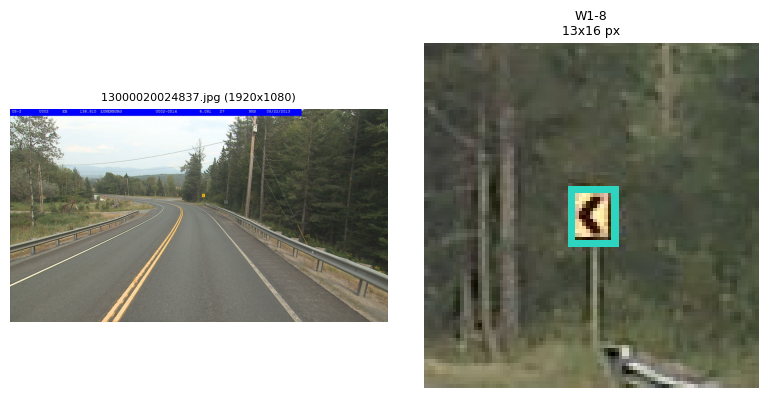

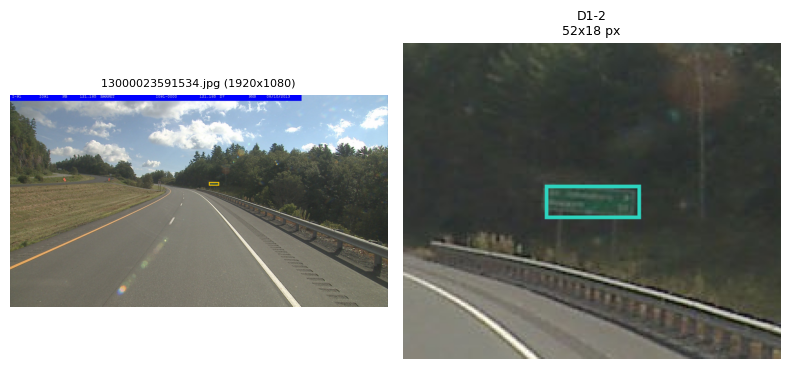

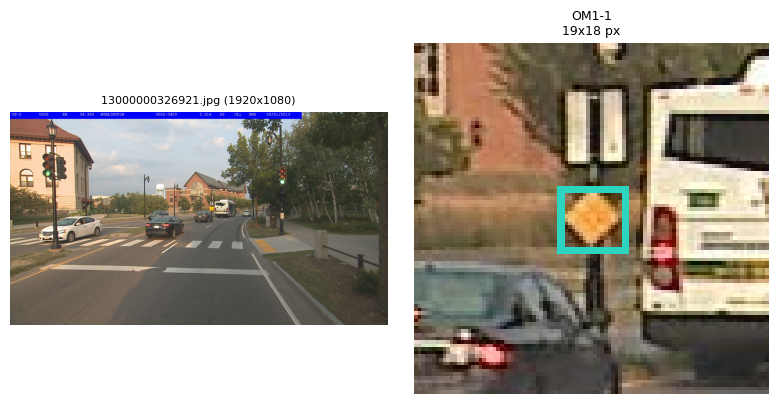

In [ ]:
# B6. Look at real labels. Two views: the whole frame, and a zoom on each sign.
from PIL import Image, ImageDraw
import random

def image_for(xml_path):
    """ARTSv2 keeps images in JPEGImages/, NOT beside the XML in Annotations/."""
    stem = os.path.splitext(os.path.basename(xml_path))[0]
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".PNG"):
        candidate = os.path.join(ARTS_ROOT, "JPEGImages", stem + ext)
        if os.path.isfile(candidate):
            return candidate
    return None

random.seed(0)
for xml_path in random.sample(xml_files, 3):
    img_path = image_for(xml_path)
    if not img_path:
        print("no image for", xml_path); continue
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall(".//object"):
        bb = obj.find("bndbox")
        if bb is None: continue
        boxes.append(([float(bb.findtext(k)) for k in ("xmin","ymin","xmax","ymax")],
                      obj.findtext("name") or "?"))
    if not boxes: continue

    im = Image.open(img_path).convert("RGB")
    marked = im.copy(); dr = ImageDraw.Draw(marked)
    for box, _ in boxes:
        dr.rectangle(box, outline=(255, 200, 0), width=5)

    fig, axes = plt.subplots(1, len(boxes) + 1, figsize=(4 * (len(boxes) + 1), 4))
    axes = np.atleast_1d(axes)
    axes[0].imshow(marked); axes[0].axis("off")
    axes[0].set_title(f"{os.path.basename(img_path)} ({im.width}x{im.height})", fontsize=8)
    for ax, (box, name) in zip(axes[1:], boxes):
        x1, y1, x2, y2 = box
        pad = max(40, (x2 - x1) * 1.5, (y2 - y1) * 1.5)
        ox, oy = max(0, x1 - pad), max(0, y1 - pad)
        crop = im.crop((ox, oy, min(im.width, x2 + pad), min(im.height, y2 + pad)))
        ImageDraw.Draw(crop).rectangle([x1-ox, y1-oy, x2-ox, y2-oy],
                                       outline=(45, 212, 191), width=2)
        ax.imshow(crop); ax.axis("off")
        ax.set_title(f"{name}\n{int(x2-x1)}x{int(y2-y1)} px", fontsize=9)
    plt.tight_layout(); plt.show()

In [ ]:
# B7. Audit the OFFICIAL split shipped in ImageSets/.
#
# ARTSv2 gives every physical sign a stable <id>. If the same signpost appears in
# both train and test, a model can score well by memorising that exact sign
# rather than learning the sign class. This measures whether that happens.
official = {}
for split in ("train", "val", "test"):
    for folder in ("Main", "Layout"):
        path = f"{ARTS_ROOT}/ImageSets/{folder}/{split}.txt"
        if os.path.isfile(path):
            for line in open(path, encoding="utf-8"):
                stem = line.strip().split()[0] if line.strip() else ""
                if stem:
                    official[stem] = split
            break

print("official split sizes:", Counter(official.values()))
listed = [p for p in per_image if p["stem"] in official]
print(f"parsed images listed in the split: {len(listed)}/{len(per_image)}")

ids = defaultdict(set)
for p in listed:
    ids[official[p["stem"]]] |= p["sign_ids"]
for split in ("train", "val", "test"):
    print(f"  {split:5s}: {len(ids[split])} distinct physical signs")

print("\nphysical signs shared between splits:")
print(f"  train & val : {len(ids['train'] & ids['val'])}")
print(f"  train & test: {len(ids['train'] & ids['test'])}")
print(f"  val   & test: {len(ids['val'] & ids['test'])}")

# The punchline: what share of eval frames show a sign the model trained on?
for split in ("val", "test"):
    frames_split = [p for p in listed if official[p["stem"]] == split]
    hit = sum(1 for p in frames_split if p["sign_ids"] & ids["train"])
    if frames_split:
        print(f"\n{split}: {hit}/{len(frames_split)} frames "
              f"({100*hit/len(frames_split):.1f}%) contain a physical sign also in train")

print("""
How to read this:
  low %  -> the official split is already clean; just use it
  high % -> official-split mAP is optimistic. Train BOTH ways
            (SPLIT_MODE=official and SPLIT_MODE=geographic) and report both.
            The gap is a genuine finding, not a flaw in your work.
""")

official split sizes: Counter({'train': 9957, 'val': 4979, 'test': 4978})
parsed images listed in the split: 19914/19914
  train: 6724 distinct physical signs
  val  : 5217 distinct physical signs
  test : 5162 distinct physical signs

physical signs shared between splits:
  train & val : 4497
  train & test: 4424
  val   & test: 3532

val: 4597/4979 frames (92.3%) contain a physical sign also in train

test: 4603/4978 frames (92.5%) contain a physical sign also in train

How to read this:
  low %  -> the official split is already clean; just use it
  high % -> official-split mAP is optimistic. Train BOTH ways
            (SPLIT_MODE=official and SPLIT_MODE=geographic) and report both.
            The gap is a genuine finding, not a flaw in your work.



## Phase C - convert to YOLO format

The converter writes to **local disk** (`/content/dataset`) for speed, then we
zip it once to Drive so later sessions skip this step entirely.

It splits train/val/test **by sequence**, never by individual frame. ARTSv2
frames are about a second apart, so a random per-image split would put the same
physical sign in both train and val and inflate mAP.

In [ ]:
# C1. Convert. Reads every image once.
#
# REQUIRES A7 to have run: converting straight off the Drive mount would take
# ~11 hours instead of ~20 minutes.
assert ARTS_ROOT.startswith("/content/"), (
    "ARTS_ROOT still points at Drive. Run cell A7 first."
)
os.environ["ARTS_ROOT"] = ARTS_ROOT
os.environ["ARTS_YOLO_OUT"] = LOCAL_DATASET
os.environ["TOP_N_CLASSES"] = "50"     # raise once you see the class distribution
os.environ["MAX_SIDE"] = "1920"        # ARTSv2 is 1920x1080 -> no downscale.
#                                      Signs can be 18 px tall; resizing erases them.
os.environ["VAL_RATIO"] = "0.15"
os.environ["TEST_RATIO"] = "0.15"
os.environ["EXPORT_SEQUENCE"] = "1"    # also export one test sequence for the demo

# "geographic" = our leak-free split (default, and the honest number to report)
# "official"   = the authors' ImageSets split (comparable to published results)
# Run B7 first. If it shows heavy leakage, do BOTH and report both -- just give
# each run its own ARTS_YOLO_OUT so the two datasets do not overwrite each other.
os.environ["SPLIT_MODE"] = "geographic"
os.environ["USE_LOOKUPS"] = "1"        # apply the authors' class normalisation

!python {REPO_DIR}/scripts/02_convert_arts_to_yolo.py

ARTS_ROOT = /content/arts_raw
OUT_DIR   = /content/dataset/arts_yolo
Found image/XML pairs: 19914

--- detecting XML field names ---
image-level tags: altitude, cam_dom, depth, filename, folder, height, latitude, longitude, width
object-level tags: assembly, difficult, id, latitude, longitude, name, side, truncated, xmax, xmin, ymax, ymin

resolved mapping (VERIFY THIS against one real XML):
  camera_lat   -> latitude
  camera_lon   -> longitude
  heading      -> cam_dom
  sign_lat     -> latitude
  sign_lon     -> longitude
  sign_id      -> id
  side         -> side
  assembly     -> assembly

loaded 425 class mappings from ImageSets/Layout/lookups.txt
  174 codes map to UNKNOWN and will be skipped

--- parsing annotations ---
frames with at least one annotation: 19914
total annotations: 35979
distinct classes: 171

--- assigning splits ---
strategy: geographic tile (~500 m), because all images share one folder
groups: 1190  (median size 12)
physical signs appearing in both train and

In [ ]:
# C2. Sanity-check the split: no sequence may appear in two splits.
import json

summary = json.load(open(f"{LOCAL_DATASET}/meta/summary.json"))
meta = json.load(open(f"{LOCAL_DATASET}/meta/frames_meta.json"))

print("split strategy:", summary["split_strategy"])
print("images:", summary["images"])
print("detected XML tags:", summary["tags"])

groups_by_split = defaultdict(set)
for m in meta["frames"].values():
    groups_by_split[m["split"]].add(m["group"])
tr, va, te = groups_by_split["train"], groups_by_split["val"], groups_by_split["test"]
print(f"\ngroups  train={len(tr)}  val={len(va)}  test={len(te)}")
overlap = (tr & va) | (tr & te) | (va & te)
print("OVERLAP:", overlap if overlap else "none - split is clean")
assert not overlap, "Split leaked. Do not train until this is empty."

print("\nclasses present per split:")
for split in ("train", "val", "test"):
    print(f"  {split:5s}: {len(summary['per_split_class_counts'].get(split, {}))} / {len(summary['classes'])}")
missing = set(summary["classes"]) - set(summary["per_split_class_counts"].get("val", {}))
if missing:
    print("  classes absent from val (their mAP will read 0):", sorted(missing))

split strategy: geographic tile (~500 m), because all images share one folder
images: {'test': 2502, 'train': 10332, 'val': 2301}
detected XML tags: {'camera_lat': 'latitude', 'camera_lon': 'longitude', 'heading': 'cam_dom', 'sign_lat': 'latitude', 'sign_lon': 'longitude', 'sign_id': 'id', 'side': 'side', 'assembly': 'assembly'}

groups  train=767  val=166  test=166
OVERLAP: none - split is clean

classes present per split:
  train: 50 / 50
  val  : 50 / 50
  test : 50 / 50


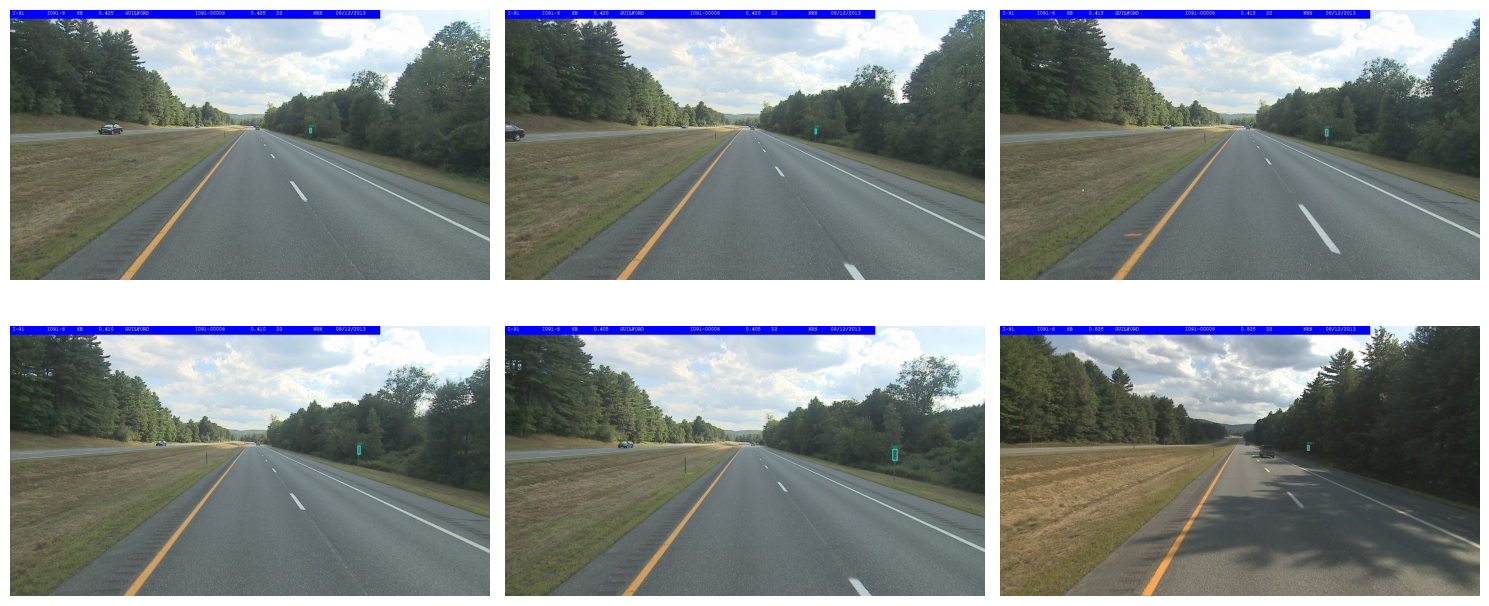

In [ ]:
# C3. Verify the CONVERTED labels by drawing them back onto a converted image.
# If boxes land in the wrong place here, the conversion maths is wrong.
import glob
names = summary["classes"]
paths = sorted(glob.glob(f"{LOCAL_DATASET}/images/train/*.jpg"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, p in zip(axes.ravel(), paths):
    im = Image.open(p).convert("RGB"); dr = ImageDraw.Draw(im)
    lbl = p.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    for line in open(lbl):
        cid, cx, cy, bw, bh = line.split()
        cx, cy, bw, bh = float(cx)*im.width, float(cy)*im.height, float(bw)*im.width, float(bh)*im.height
        dr.rectangle([cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2], outline=(45, 212, 191), width=4)
        dr.text((cx-bw/2, max(0, cy-bh/2-14)), names[int(cid)], fill=(45, 212, 191))
    ax.imshow(im); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# C4. Cache the converted dataset on Drive as a single zip.
# One big file copies far faster than 25k small ones, and next session just unzips it.
!cd /content/dataset && zip -q -r -0 /content/arts_yolo.zip arts_yolo
!ls -lh /content/arts_yolo.zip
!cp /content/arts_yolo.zip "{DATASET_ZIP}"
print("cached ->", DATASET_ZIP)

-rw-r--r-- 1 root root 6.2G Aug 13 19:46 /content/arts_yolo.zip
cached -> /content/drive/MyDrive/traffic-sign-inventory/datasets/arts_yolo.zip


## Phase D - train

**Every new session starts at D1.** The local disk is wiped when the runtime
dies, so the dataset must be unzipped again before training or resuming.

In [4]:
# D0. What is actually on Drive?
import os, time
w = f"{PROJECT}/{NAME}/weights"
if os.path.isdir(w):
    for f in sorted(os.listdir(w)):
        p = os.path.join(w, f)
        print(f"{f:16s} {os.path.getsize(p)/1e6:7.1f} MB  {time.ctime(os.path.getmtime(p))}")
else:
    print("no run directory yet:", w)

csv = f"{PROJECT}/{NAME}/results.csv"
if os.path.isfile(csv):
    lines = open(csv).read().strip().splitlines()
    print(f"\n{len(lines)-1} epochs completed")
    print("last row:", lines[-1])

best.pt              5.6 MB  Fri Aug 14 16:52:11 2026
epoch0.pt           21.4 MB  Thu Aug 13 20:15:28 2026
epoch10.pt          21.4 MB  Thu Aug 13 22:31:32 2026
epoch12.pt          21.4 MB  Thu Aug 13 22:57:58 2026
epoch14.pt          21.4 MB  Thu Aug 13 23:26:23 2026
epoch16.pt          21.4 MB  Thu Aug 13 23:58:44 2026
epoch18.pt          21.4 MB  Fri Aug 14 09:36:20 2026
epoch2.pt           21.4 MB  Thu Aug 13 20:42:58 2026
epoch20.pt          21.4 MB  Fri Aug 14 10:02:23 2026
epoch22.pt          21.4 MB  Fri Aug 14 10:28:32 2026
epoch24.pt          21.4 MB  Fri Aug 14 10:54:43 2026
epoch26.pt          21.4 MB  Fri Aug 14 11:21:03 2026
epoch28.pt          21.4 MB  Fri Aug 14 12:02:14 2026
epoch30.pt          21.4 MB  Fri Aug 14 12:28:05 2026
epoch32.pt          21.4 MB  Fri Aug 14 15:14:56 2026
epoch34.pt          21.4 MB  Fri Aug 14 15:36:49 2026
epoch36.pt          21.4 MB  Fri Aug 14 16:11:26 2026
epoch38.pt          21.4 MB  Fri Aug 14 16:34:28 2026
epoch4.pt           21.4 MB 

In [5]:
# D1. RUN THIS FIRST IN EVERY SESSION. Restores the dataset to local disk.
import os
if os.path.isfile(f"{LOCAL_DATASET}/data.yaml"):
    print("dataset already on local disk")
else:
    assert os.path.isfile(DATASET_ZIP), f"No cached zip at {DATASET_ZIP}. Run Phase C."
    !mkdir -p /content/dataset
    !cp "{DATASET_ZIP}" /content/arts_yolo.zip
    !unzip -q -o /content/arts_yolo.zip -d /content/dataset
    print("restored")

assert os.path.isfile(DATA_YAML), DATA_YAML
!echo "train:" && ls {LOCAL_DATASET}/images/train | wc -l
!echo "val:"   && ls {LOCAL_DATASET}/images/val   | wc -l
!echo "test:"  && ls {LOCAL_DATASET}/images/test  | wc -l

restored
train:
10332
val:
2301
test:
2502


In [ ]:
# D2a. Park the smoke-test run so the real run starts clean.
import shutil, os
run_dir = f"{PROJECT}/{NAME}"
if os.path.isdir(run_dir):
    dest = f"{PROJECT}/{NAME}_smoketest"
    shutil.rmtree(dest, ignore_errors=True)
    shutil.move(run_dir, dest)
    print("parked ->", dest)
else:
    print("nothing to park")

parked -> /content/drive/MyDrive/traffic-sign-inventory/runs/yolo11n_arts_smoketest


In [ ]:
# RECOVER: D2a mis-parked the REAL run. Put it back.
import shutil, os, yaml

parked = f"{PROJECT}/{NAME}_smoketest"
real   = f"{PROJECT}/{NAME}"

cfg  = yaml.safe_load(open(f"{parked}/args.yaml"))
rows = len(open(f"{parked}/results.csv").read().strip().splitlines()) - 1
print(f"parked: imgsz={cfg.get('imgsz')} epochs={cfg.get('epochs')} "
      f"fraction={cfg.get('fraction')}  completed={rows}")

assert cfg.get("imgsz") == 1280 and cfg.get("epochs") == 40, "NOT the real run - stop and tell me"
assert not os.path.isdir(real), f"{real} already exists - inspect before moving"

shutil.move(parked, real)
print("restored ->", real)
print("weights:", sorted(os.listdir(f"{real}/weights")))

parked: imgsz=1280 epochs=40 fraction=1.0  completed=39
restored -> /content/drive/MyDrive/traffic-sign-inventory/runs/yolo11n_arts
weights: ['best.pt', 'epoch0.pt', 'epoch10.pt', 'epoch12.pt', 'epoch14.pt', 'epoch16.pt', 'epoch18.pt', 'epoch2.pt', 'epoch20.pt', 'epoch22.pt', 'epoch24.pt', 'epoch26.pt', 'epoch28.pt', 'epoch30.pt', 'epoch32.pt', 'epoch34.pt', 'epoch36.pt', 'epoch38.pt', 'epoch4.pt', 'epoch6.pt', 'epoch8.pt', 'last.pt']


In [ ]:
# D2. REAL TRAINING. Run this once; use D3 to resume after a disconnect.
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(
    data=DATA_YAML,
    epochs=40,
    imgsz=1280,        # B3: median sign is 26 px at native 1920. At 960 that
    #                    becomes 13 px and ~20% of signs drop below the P3
    #                    stride entirely. Do not lower this.
    batch=8,           # drop to 4 on CUDA OOM before touching imgsz
    workers=2,
    cache=False,       # caching 10k images at 1280 would exhaust Colab RAM
    device=0,
    project=PROJECT,   # on Drive, so checkpoints survive a disconnect
    name=NAME,
    exist_ok=True,
    save=True,
    save_period=2,     # checkpoint every 2 epochs
    patience=12,       # stop if val mAP stalls, saving quota
    seed=0,
    plots=True,
    resume=False,
)

New https://pypi.org/project/ultralytics/8.4.119 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/arts_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mod

### Resume after a disconnect or quota reset

1. Reconnect the runtime, set it back to GPU
2. Re-run **A1, A2, A3**, then **D1** (the unzip)
3. Run **D3** below - not D2

The dataset must sit at the same local path as before, which is exactly what D1
guarantees.

In [ ]:
# D3. RESUME from the last Drive checkpoint
from ultralytics import YOLO
import os

LAST = f"{PROJECT}/{NAME}/weights/last.pt"
assert os.path.isfile(LAST), f"No checkpoint at {LAST} - nothing to resume."
assert os.path.isfile(DATA_YAML), "Run D1 first: the dataset is not on local disk."

print("resuming from", LAST)
model = YOLO(LAST)
model.train(resume=True)

resuming from /content/drive/MyDrive/traffic-sign-inventory/runs/yolo11n_arts/weights/last.pt
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/arts_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7909dc74dc70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.

## Phase E - evaluate

`val` chose the checkpoint, so scoring on it is optimistic. The number you
report is the **test** split, which no training decision ever touched.

In [ ]:
# E1. Validation and held-out test metrics
from ultralytics import YOLO
import os

BEST = f"{PROJECT}/{NAME}/weights/best.pt"
assert os.path.isfile(BEST), f"Missing {BEST}"
model = YOLO(BEST)

print("=== val split (used for checkpoint selection) ===")
val_m = model.val(data=DATA_YAML, split="val", plots=True)
print(f"mAP50 {val_m.box.map50:.4f}   mAP50-95 {val_m.box.map:.4f}")

print("\n=== test split (report THIS one) ===")
test_m = model.val(data=DATA_YAML, split="test", plots=True)
print(f"mAP50 {test_m.box.map50:.4f}   mAP50-95 {test_m.box.map:.4f}")
print(f"precision {test_m.box.mp:.4f}   recall {test_m.box.mr:.4f}")

=== val split (used for checkpoint selection) ===
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,591,902 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2707.0±981.0 MB/s, size: 405.7 KB)
val: Scanning /content/dataset/arts_yolo/labels/val.cache... 2301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2301/2301 877.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 144/144 2.5it/s 56.7s
                   all       2301       3867      0.725      0.711      0.745      0.534
                 D10-2        393        393      0.951      0.987      0.991      0.643
                 W11-2        183        197      0.918      0.909      0.959      0.767
                WT-100        154        286      0.856      0.788      0.865      0.597
                 W16-7        123        131      0.875      0.817  

In [ ]:
# E2. Per-class results. A single averaged mAP hides everything with 30 classes.
import json
names = json.load(open(f"{LOCAL_DATASET}/meta/summary.json"))["classes"]
counts = json.load(open(f"{LOCAL_DATASET}/meta/summary.json"))["class_counts"]

rows = []
for i, ap50 in enumerate(test_m.box.ap50):
    cid = int(test_m.box.ap_class_index[i])
    rows.append((names[cid], counts.get(names[cid], 0), float(ap50), float(test_m.box.ap[i])))
rows.sort(key=lambda r: -r[2])

print(f"{'class':32s} {'train n':>8s} {'AP50':>7s} {'AP50-95':>8s}")
for name, n, ap50, ap in rows:
    print(f"{name[:32]:32s} {n:8d} {ap50:7.3f} {ap:8.3f}")

weak = [r for r in rows if r[2] < 0.3]
print(f"\n{len(weak)} classes below AP50 0.30 - usually the rarest ones.")
print("Fix by lowering TOP_N_CLASSES, or merging rare classes, not by training longer.")

class                             train n    AP50  AP50-95
E5-1                                  258   0.991    0.732
D10-2                                2423   0.991    0.622
VR-132                                204   0.988    0.601
D10-3                                 655   0.986    0.640
D10-1                                 553   0.984    0.607
VR-141                                299   0.982    0.675
E1-5                                  636   0.969    0.586
WT-100                               1152   0.936    0.652
D9-18                                 214   0.929    0.681
W11-2                                1495   0.928    0.754
W1-6                                  227   0.928    0.702
W16-7                                1133   0.927    0.604
R3-4                                  847   0.926    0.642
R1-1                                  494   0.921    0.669
W4-1                                  403   0.908    0.686
S1-1                                  332   0.903    0.6

/content/drive/MyDrive/traffic-sign-inventory/runs/yolo11n_arts/confusion_matrix_normalized.png


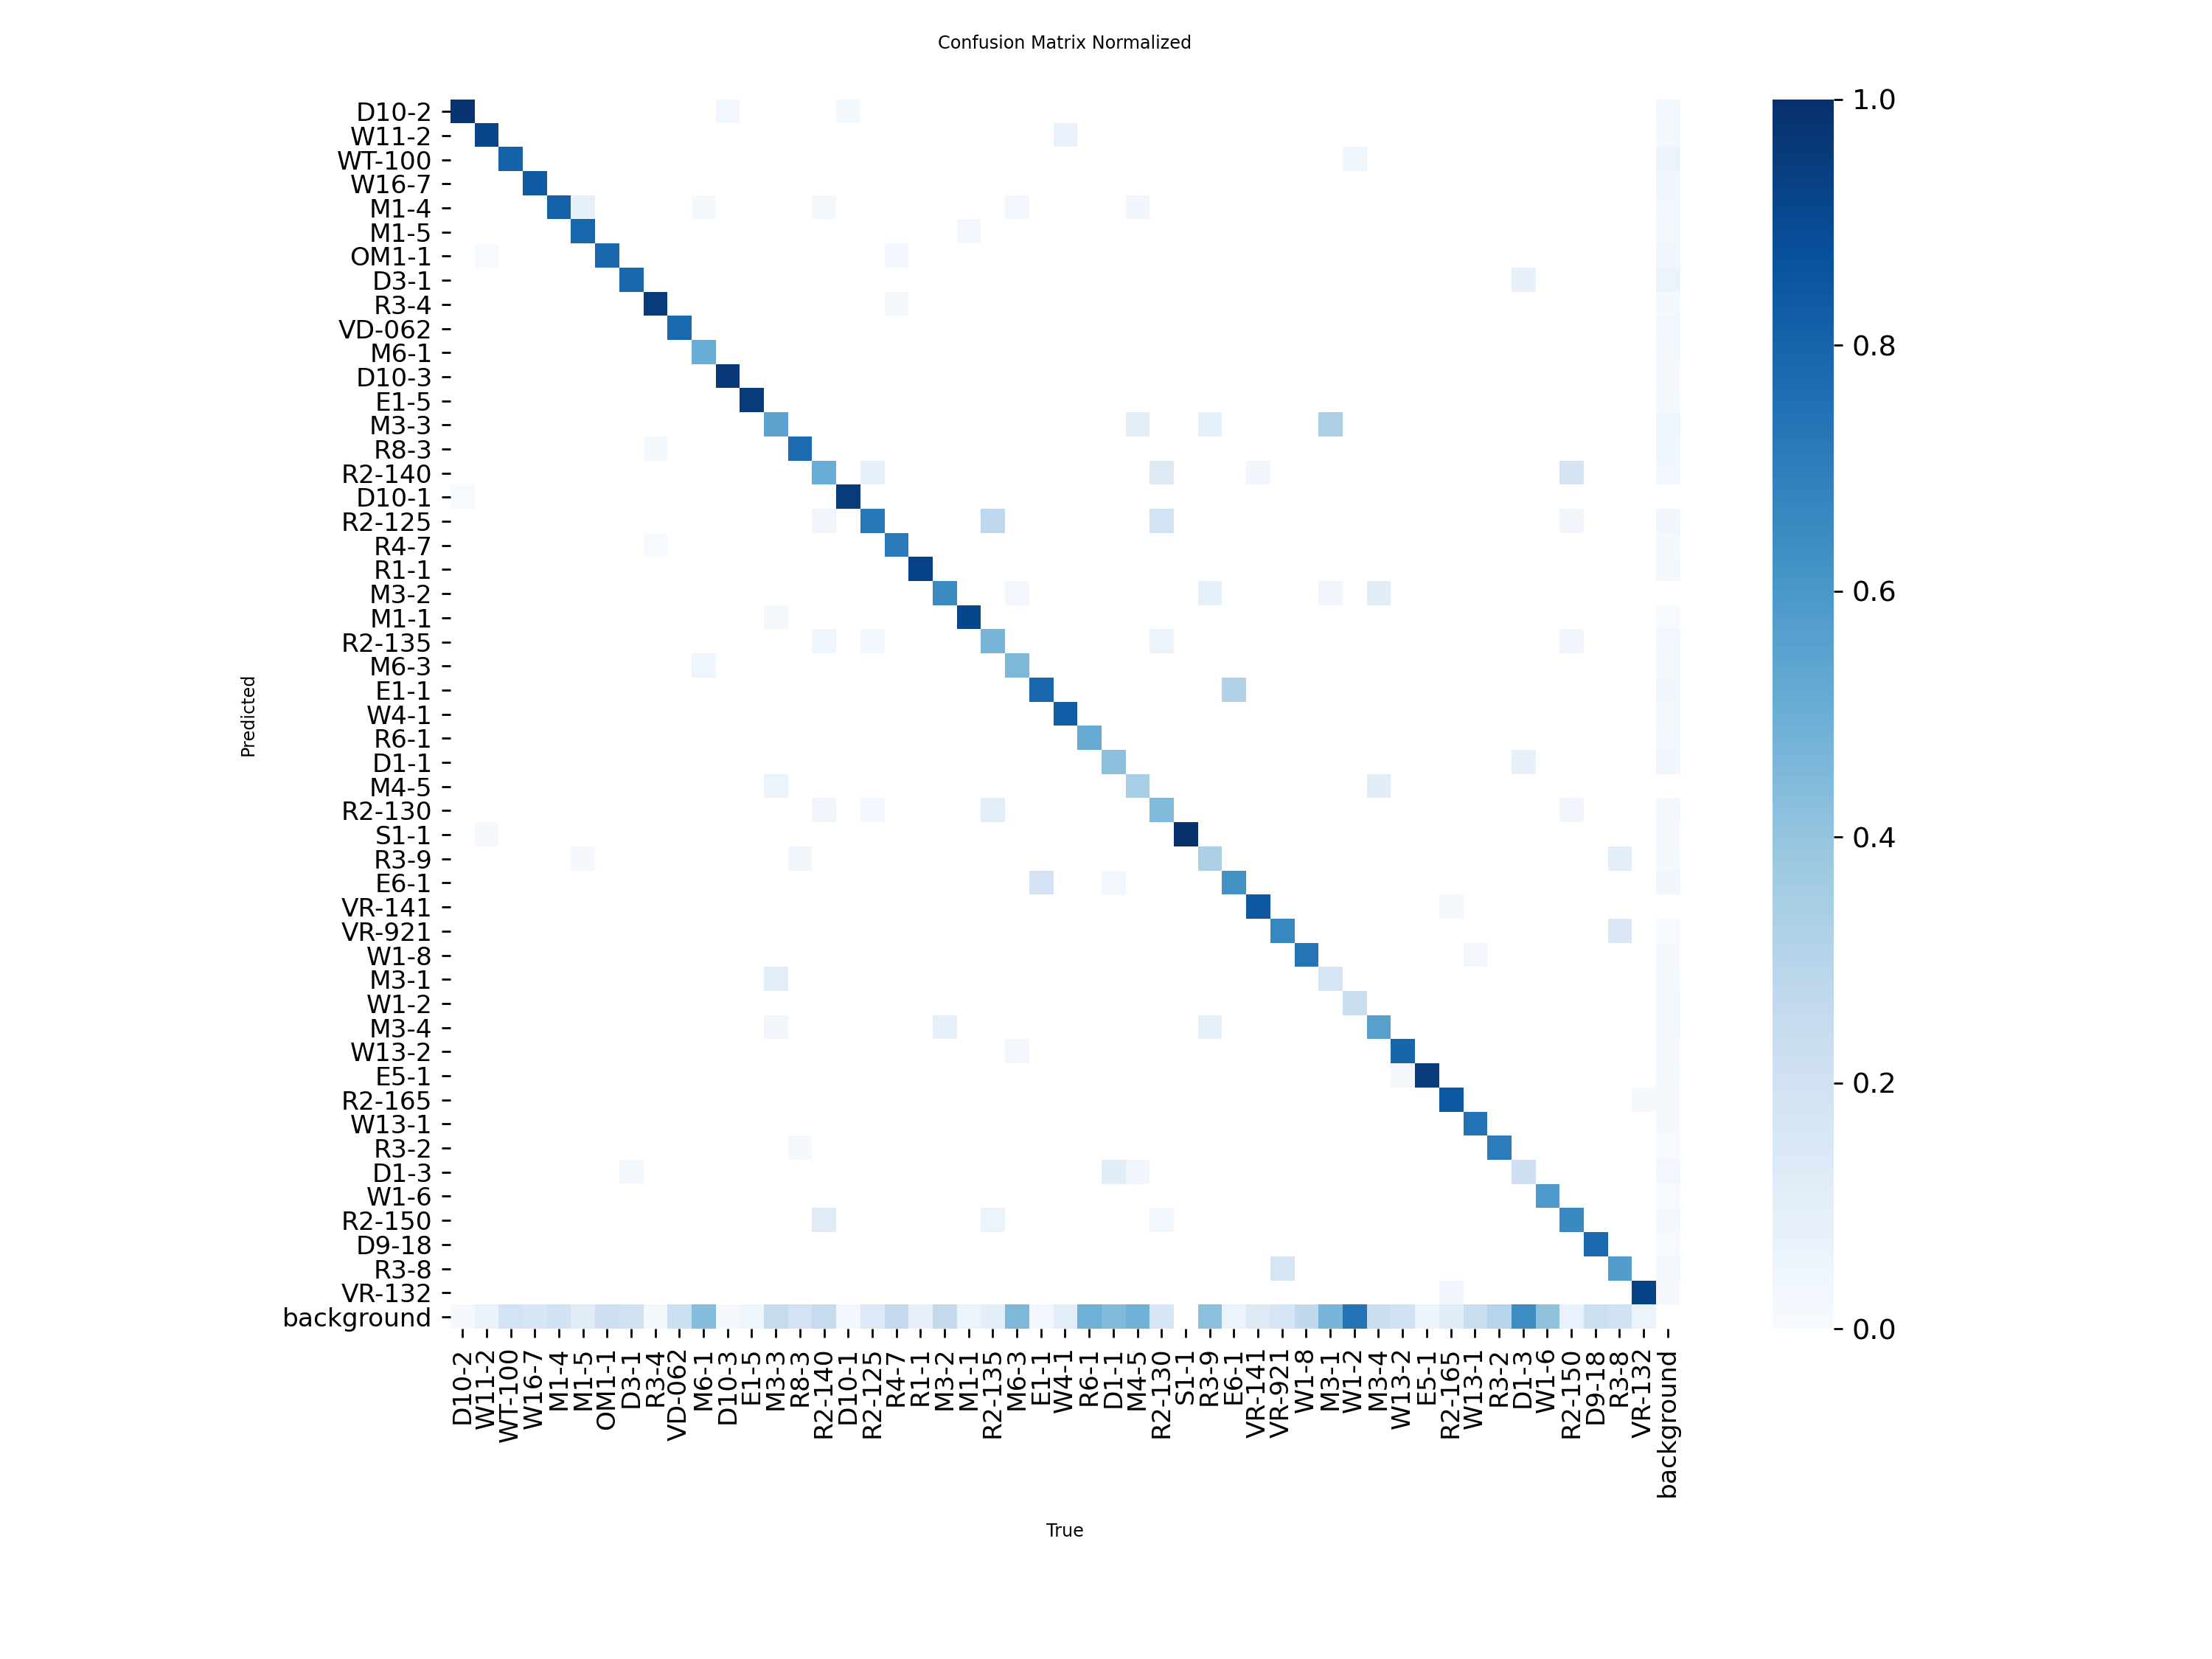

/content/drive/MyDrive/traffic-sign-inventory/runs/yolo11n_arts/results.png


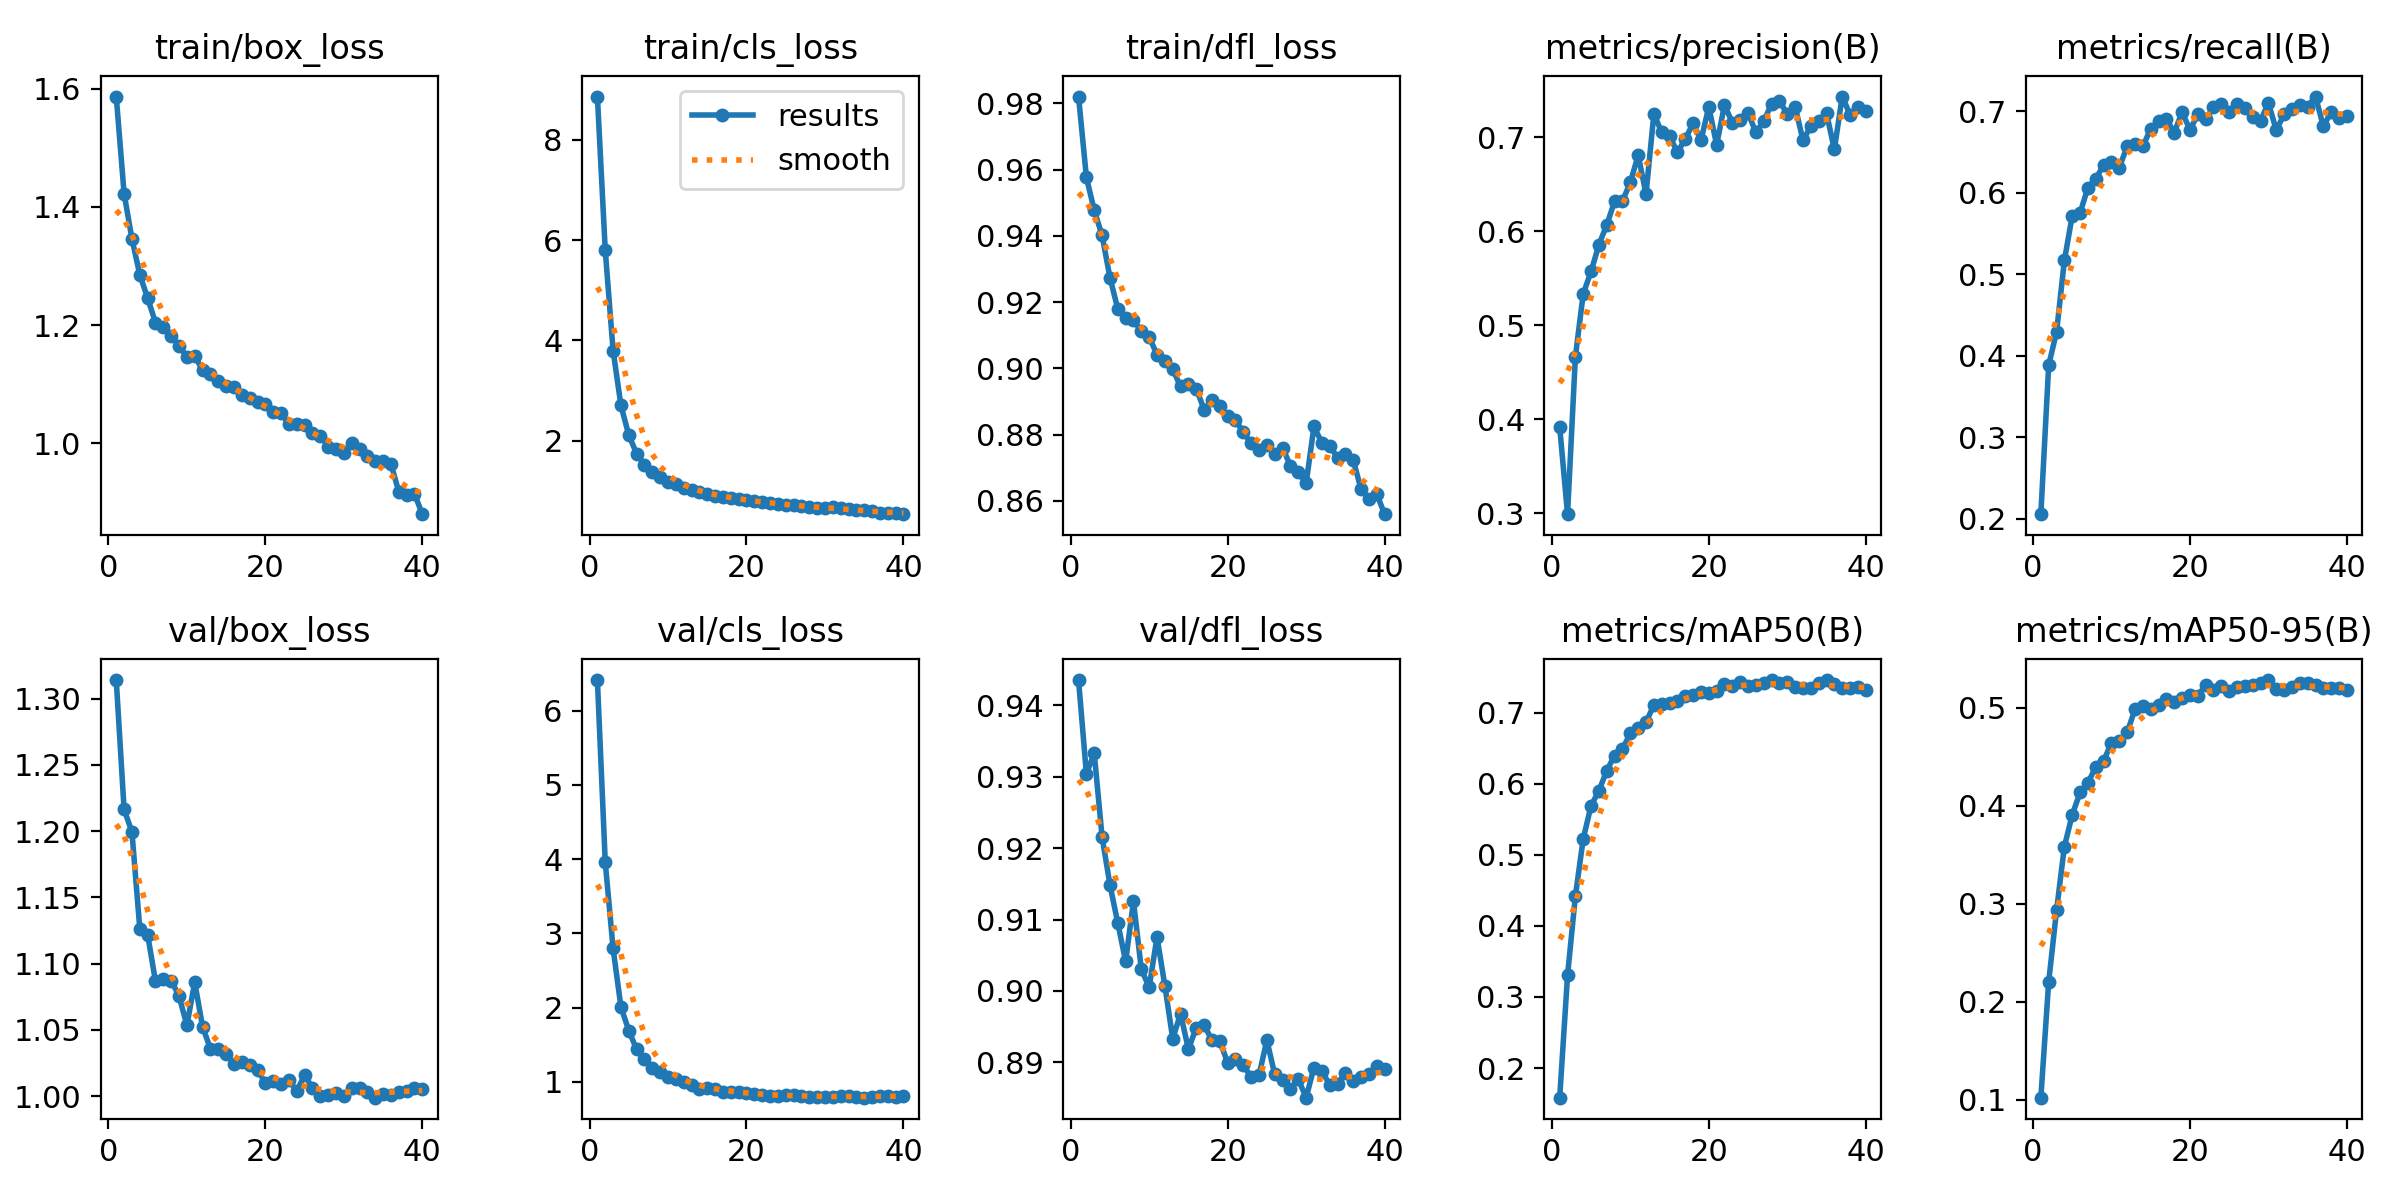

In [ ]:
# E3. Confusion matrix and curves that Ultralytics already saved
from IPython.display import Image as ShowImage, display
import glob

for pattern in ("confusion_matrix_normalized.png", "results.png", "PR_curve.png"):
    for path in sorted(glob.glob(f"{PROJECT}/{NAME}*/**/{pattern}", recursive=True))[-1:]:
        print(path)
        display(ShowImage(filename=path, width=760))

In [ ]:
# E4. Export the artefacts you need locally
import shutil, os
EXPORT = f"{DRIVE_ROOT}/export"
os.makedirs(EXPORT, exist_ok=True)

shutil.copy(f"{PROJECT}/{NAME}/weights/best.pt", f"{EXPORT}/best.pt")
shutil.copy(f"{LOCAL_DATASET}/classes.txt", f"{EXPORT}/classes.txt")
shutil.copy(f"{LOCAL_DATASET}/meta/summary.json", f"{EXPORT}/summary.json")

# the demo sequence, so the local pipeline has real frames with real GPS
demo_src = f"{LOCAL_DATASET}/demo_sequence"
if os.path.isdir(demo_src):
    shutil.make_archive(f"{EXPORT}/demo_sequence", "zip", demo_src)
    print("demo_sequence.zip:", len(os.listdir(demo_src)), "files")

print("\nDownload from Drive:", EXPORT)
print("  best.pt          -> weights/best.pt in the project")
print("  demo_sequence.zip -> unzip into data/demo_sequence/")
!du -sh "{EXPORT}"/*

demo_sequence.zip: 70 files

Download from Drive: /content/drive/MyDrive/traffic-sign-inventory/export
  best.pt          -> weights/best.pt in the project
  demo_sequence.zip -> unzip into data/demo_sequence/
5.3M	/content/drive/MyDrive/traffic-sign-inventory/export/best.pt
512	/content/drive/MyDrive/traffic-sign-inventory/export/classes.txt
28M	/content/drive/MyDrive/traffic-sign-inventory/export/demo_sequence.zip
5.0K	/content/drive/MyDrive/traffic-sign-inventory/export/summary.json


## Phase F - export several test sequences

One 69-frame sequence gives a 35-sign sample: enough to prove the pipeline runs,
not enough to trust a number. This exports every sizeable road stretch in the
**test** split as its own sequence, so the local evaluation can pool hundreds of
signs and hold some sequences back for calibration.

Needs only cells A1, A2, A3 and D1 (the dataset restore). No GPU required.

In [ ]:
# F1. Export every test-split road stretch as a separate sequence.
import os, json, shutil
from collections import defaultdict

MIN_FRAMES = 20      # skip stretches too short to associate anything
MAX_SEQS   = 30      # cap the download size

assert os.path.isfile(f"{LOCAL_DATASET}/meta/frames_meta.json"), "run D1 first"
meta = json.load(open(f"{LOCAL_DATASET}/meta/frames_meta.json"))
frames = meta["frames"]

groups = defaultdict(list)
for stem, m in frames.items():
    if m["split"] == "test":
        groups[m["group"]].append(stem)

ranked = sorted(((g, s) for g, s in groups.items() if len(s) >= MIN_FRAMES),
                key=lambda kv: -len(kv[1]))[:MAX_SEQS]
print(f"test stretches with >= {MIN_FRAMES} frames: "
      f"{sum(1 for s in groups.values() if len(s) >= MIN_FRAMES)}  (exporting {len(ranked)})")

out_root = "/content/sequences"
shutil.rmtree(out_root, ignore_errors=True)
os.makedirs(out_root, exist_ok=True)

total_frames = total_signs = 0
for group, stems in ranked:
    safe = group.replace("/", "-")
    seq_dir = os.path.join(out_root, f"seq_{safe}")
    os.makedirs(seq_dir, exist_ok=True)
    stems = sorted(stems, key=lambda s: s.split("__")[-1])   # driving order
    seq_meta = {}
    for stem in stems:
        src = f"{LOCAL_DATASET}/images/test/{stem}.jpg"
        if not os.path.isfile(src):
            continue
        shutil.copy2(src, os.path.join(seq_dir, stem + ".jpg"))
        seq_meta[stem] = frames[stem]
    with open(os.path.join(seq_dir, "frames_meta.json"), "w") as f:
        json.dump({"tags": meta.get("tags", {}), "frames": seq_meta}, f)
    ids = {o["sign_id"] for m in seq_meta.values()
           for o in m["objects"] if o.get("sign_id")}
    total_frames += len(seq_meta); total_signs += len(ids)
    print(f"  seq_{safe:<16s} {len(seq_meta):4d} frames  {len(ids):3d} distinct signs")

print(f"\nTOTAL: {len(ranked)} sequences  {total_frames} frames  {total_signs} distinct signs")
shutil.make_archive(f"{DRIVE_ROOT}/export/sequences", "zip", out_root)
print(f"\nsequences.zip -> {DRIVE_ROOT}/export/  "
      f"({os.path.getsize(f'{DRIVE_ROOT}/export/sequences.zip')/1e6:.0f} MB)")

test stretches with >= 20 frames: 42  (exporting 30)
  seq_8852_-14516        86 frames  150 distinct signs
  seq_8795_-14425        74 frames   15 distinct signs
  seq_8849_-14510        69 frames   35 distinct signs
  seq_8839_-14500        68 frames   32 distinct signs
  seq_8578_-14511        56 frames   16 distinct signs
  seq_8987_-14442        44 frames   62 distinct signs
  seq_8895_-14640        42 frames   12 distinct signs
  seq_8884_-14403        40 frames   38 distinct signs
  seq_8852_-14517        39 frames   28 distinct signs
  seq_8593_-14503        35 frames    9 distinct signs
  seq_8884_-14404        34 frames   27 distinct signs
  seq_8749_-14452        33 frames    6 distinct signs
  seq_8730_-14467        33 frames    7 distinct signs
  seq_8835_-14501        33 frames   22 distinct signs
  seq_8851_-14519        32 frames   15 distinct signs
  seq_8894_-14637        31 frames   13 distinct signs
  seq_8853_-14499        30 frames    3 distinct signs
  seq_8570_-

## Phase G - second-stage crop classifier

The detector finds signs well but confuses variants inside a family: M3-1/2/3/4
are the same rectangle with a different word (NORTH/SOUTH/EAST/WEST), R2-125 to
R2-165 differ only by the number. At a 26 px median height that text is not
resolvable in the full frame, and those classes dominate the bottom of the
per-class AP table.

Two-stage fix: the detector decides *where* and *which family*, then a small
classifier reads the upscaled crop to pick the variant. 34 of the 50 classes are
in multi-member families, so this covers most of the error.

Needs A1, A2, A3 and D1. G2 wants a GPU but only for a few minutes.

In [6]:
# G1. Extract ground-truth crops for every class in a multi-member family.
import os, json, re, shutil, random
from collections import defaultdict, Counter
from PIL import Image

PAD_FRAC = 0.15      # context around the box; predicted boxes are never exact
OUT_PX   = 128       # cap stored crop size (training resizes down anyway)
MAX_PER_CLASS = 2000 # cap the dominant classes so the tail is learnable
MIN_PER_CLASS = 30

meta = json.load(open(f"{LOCAL_DATASET}/meta/frames_meta.json"))["frames"]
classes = [l.strip() for l in open(f"{LOCAL_DATASET}/classes.txt") if l.strip()]

families = defaultdict(list)
for c in classes:
    m = re.match(r"^([A-Za-z]+\d*)-", c)
    families[m.group(1) if m else c].append(c)
confusable = {c for fam in families.values() if len(fam) > 1 for c in fam}
print(f"{len(classes)} classes -> {len(confusable)} in multi-member families")

# gather every ground-truth box of a confusable class
by_split = defaultdict(lambda: defaultdict(list))
for stem, m in meta.items():
    split = m["split"]
    if split == "test":
        continue                      # test stays untouched for final scoring
    for o in m.get("objects", []):
        if o["name"] in confusable:
            by_split[split][o["name"]].append((stem, o["bbox"]))

random.seed(0)
root = "/content/crop_cls"
shutil.rmtree(root, ignore_errors=True)

counts = Counter()
for split, per_class in by_split.items():
    for cls, items in per_class.items():
        if len(items) < MIN_PER_CLASS and split == "train":
            print(f"  skipping {cls}: only {len(items)} train crops")
            continue
        random.shuffle(items)
        items = items[:MAX_PER_CLASS]
        out_dir = os.path.join(root, split, cls.replace("/", "-"))
        os.makedirs(out_dir, exist_ok=True)
        for i, (stem, box) in enumerate(items):
            src = f"{LOCAL_DATASET}/images/{split}/{stem}.jpg"
            if not os.path.isfile(src):
                continue
            try:
                im = Image.open(src).convert("RGB")
            except OSError:
                continue
            x1, y1, x2, y2 = box
            pad = max(4.0, PAD_FRAC * max(x2 - x1, y2 - y1))
            crop = im.crop((max(0, x1 - pad), max(0, y1 - pad),
                            min(im.width, x2 + pad), min(im.height, y2 + pad)))
            if crop.width < 4 or crop.height < 4:
                continue
            if max(crop.size) > OUT_PX:
                crop.thumbnail((OUT_PX, OUT_PX), Image.LANCZOS)
            crop.save(os.path.join(out_dir, f"{stem}_{i}.jpg"), quality=92)
            counts[(split, cls)] += 1

for split in ("train", "val"):
    total = sum(v for (s, _), v in counts.items() if s == split)
    n_cls = len({c for (s, c) in counts if s == split})
    print(f"{split}: {total} crops across {n_cls} classes")

print("\nsmallest train classes:")
train_counts = sorted(((c, v) for (s, c), v in counts.items() if s == "train"),
                      key=lambda kv: kv[1])
for c, v in train_counts[:8]:
    print(f"  {c:10s} {v}")

shutil.make_archive(f"{DRIVE_ROOT}/export/crop_cls_dataset", "zip", root)
print(f"\ndataset -> {DRIVE_ROOT}/export/crop_cls_dataset.zip")

50 classes -> 34 in multi-member families
train: 11232 crops across 34 classes
val: 2173 crops across 34 classes

smallest train classes:
  VR-132     113
  R3-8       134
  R3-2       135
  W13-1      144
  W13-2      149
  R2-165     158
  W1-6       164
  R2-150     167

dataset -> /content/drive/MyDrive/traffic-sign-inventory/export/crop_cls_dataset.zip


In [7]:
# G2. Train the crop classifier.
from ultralytics import YOLO
import os

CLS_PROJECT = f"{DRIVE_ROOT}/runs"
CLS_NAME = "crop_cls"

cls_model = YOLO("yolo11n-cls.pt")
cls_model.train(
    data="/content/crop_cls",
    epochs=40,
    imgsz=96,          # crops are tiny; 96 gives the CNN room without inventing detail
    batch=128,
    device=0,
    project=CLS_PROJECT,
    name=CLS_NAME,
    exist_ok=True,
    save_period=5,
    patience=10,
    seed=0,
)

best_cls = f"{CLS_PROJECT}/{CLS_NAME}/weights/best.pt"
metrics = YOLO(best_cls).val(data="/content/crop_cls")
print(f"\ntop-1 accuracy: {metrics.top1:.4f}")
print(f"top-5 accuracy: {metrics.top5:.4f}")

import shutil
shutil.copy(best_cls, f"{DRIVE_ROOT}/export/crop_classifier.pt")
print(f"\ncrop_classifier.pt -> {DRIVE_ROOT}/export/  "
      f"({os.path.getsize(best_cls)/1e6:.1f} MB)")
print("Download it to weights/crop_classifier.pt on your local machine.")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crop_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=96, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=crop_cls, nbs=64, nms=False, opset=None,